# Notebook to perform QC of CosMX RNA Data

# TODO
- xx

## Instructions

- Create an environment that has relevant and required packages installed (see env_setup.sh as starting point)
- Helper functions are defined in helper_functions.R (imported with other imports)
- The script assumes that data was exported from AtoMx as Seurat objects (rds). Place those files in a folder and define it here as data_dir. The script will load all objects in that folder
- Manual Annotation per CosMx Slide: If a CosMx slide has multiple samples, it is required to manually match FOVs to those samples. This can be done by looking on the AtoMx platform and noting down the FOVs that correspond to a sample. Additional meta data on a sample-level should also be defined manually. Helpers are defined to streamline this process.

## Imports

In [66]:
# Load Packages
library(Seurat)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(harmony)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(cluster)
library(ggrepel)
library(gtools)
library(tibble)
library(scPearsonPCA)

In [67]:
# Load helper functions
source("helper_functions.R")

## Data Loading

In [68]:
# Define directories
data_dir <- "../raw_data/TMA18" # Folder containing Seurat objects
metadata_file <- "../inputs/sample_metadata.csv"
metadata_details_file <- "../inputs/sample_metadata_details.csv"
fov_assignment_map_file <- "../inputs/TMA_FOV_DATA_PROCESSED.csv"
out_dir <- "../outputs" # Folder for outputs
study_name <- "TMA18"
out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
out_dir <- file.path(out_dir, study_name, "QC")
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)

In [69]:
# # Load Seurat object from file (e.g. FastReSeg object)
# seu <- readRDS(file.path("/Users/fs2829/Documents/CosMX/ADANA/PIPELINE/output/TMA18/seurat_objects/fastreseg_object_TMA18.RDS"))
# all_seurat_objects <- list(TMA18 = seu)

In [70]:
# # Load Seurat objects from folder into list
all_seurat_objects <- load_seurat_objects(data_dir, assays_to_remove = c("QC_Normalization.RNA.1_1", "Initial.pipeline.run_Normalization.RNA.1_1"))
print("successfully loaded all seurat objects")

[1] "../raw_data/TMA18/seuratObject_TMA18.RDS"
[1] "TMA18"
[1] "Removing assay: Initial.pipeline.run_Normalization.RNA.1_1"
[1] "successfully loaded all seurat objects"


In [71]:
# Update Seurat objects (removes images, as presence of images breaks subsetting)
for (slide_name in names(all_seurat_objects)) {
    message("Updating Seurat object: ", slide_name)
    all_seurat_objects[[slide_name]]@images <- list()
    all_seurat_objects[[slide_name]] <- suppressWarnings(suppressMessages(UpdateSeuratObject(all_seurat_objects[[slide_name]])))
    # Create the logical flag in metadata
    # Define thresholds
    min_px <- 36
    max_px <- 4220
    if ("x_FOV_px" %in% colnames(all_seurat_objects[[slide_name]]@meta.data) && "y_FOV_px" %in% colnames(all_seurat_objects[[slide_name]]@meta.data)) {
        all_seurat_objects[[slide_name]]@meta.data$fov_border_proximity <- ifelse(
        all_seurat_objects[[slide_name]]@meta.data$x_FOV_px < min_px | all_seurat_objects[[slide_name]]@meta.data$x_FOV_px > max_px | 
        all_seurat_objects[[slide_name]]@meta.data$y_FOV_px < min_px | all_seurat_objects[[slide_name]]@meta.data$y_FOV_px > max_px, 
        "border", "interior"
        )
    }
}

Updating Seurat object: TMA18



## Manual Annotations per Slide

This section is project specific and should be adjusted accordingly

In [72]:
# Load CSV with metadata
metadata_csv <- process_tma_csv(file.path(metadata_file))
head(metadata_csv)

metadata_details_csv <- read.csv(file.path(metadata_details_file), header = TRUE, stringsAsFactors = FALSE)

study_id,tma_number,location,batch,type
<chr>,<chr>,<chr>,<chr>,<chr>
0040-79,1,D2,1,T
0040-79,1,E2,1,T
0040-79,1,F2,1,T
0040-79,1,G2,1,N
0048-05,1,A3,1,T
0048-05,1,B3,1,T


In [73]:
# Add metadata
for (slide_name in names(all_seurat_objects)) {
  # Add slide_id metadata = slide_name
  slide_number <- sub("^TMA", "", slide_name)
  all_seurat_objects[[slide_name]]$slide_id <- slide_number
  all_seurat_objects[[slide_name]]$slide_id <- as.character(all_seurat_objects[[slide_name]]$slide_id)
}

In [74]:
print(names(all_seurat_objects))
all_seurat_objects

[1] "TMA18"


$TMA18
An object of class Seurat 
6518 features across 231096 samples within 3 assays 
Active assay: RNA (6175 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: falsecode, negprobes
 2 dimensional reductions calculated: Initial.pipeline.run_UMAP.1_1, Initial.pipeline.run_PCA.1_1


In [75]:
# Check border assignment
tab <- table(all_seurat_objects[[1]]@meta.data$fov_border_proximity, useNA = "no")
names(tab)

[1] "border"   "interior"

### Slide 1

In [76]:
# # helper function to assign FOVs to samples
# borders_df <- read.csv(file.path(fov_assignment_map_file), stringsAsFactors = FALSE)

# # Create named list: parse each borders string into an actual R vector
# borders_list <- setNames(
#   lapply(borders_df$borders, function(x) eval(parse(text = x))),
#   borders_df$TMA
# )

# slide_name <- "TMA18"       # Adjust manually
# make_casewhen(borders_list[[slide_name]])
# # make_casewhen(c(8, 14, 22, 30, 38, 46, 54, 62, 68, 76, 84, 92, 100, 107, 115, 123, 131, 139, 147, 155, 161, 169, 176, 184, 192, 200, 208, 214, 221, 229, 236, 244, 252, 259, 266, 274, 283, 291, 299, 307, 315, 323, 331, 339, 346, 354, 360, 368, 376, 384, 392, 400, 408, 416, 424, 432, 440, 444, 452, 459, 467, 475, 483, 491, 499, 507, 515))

In [ ]:
slide_name <- "TMA18"       # Adjust manually
seu.obj <- all_seurat_objects[[slide_name]]

# Manually adjust the assignment of FOVs to cores
seu.obj@meta.data <- seu.obj@meta.data %>%
  mutate(region = case_when(
    fov %in% 1:8 ~ "1",
    fov %in% 9:14 ~ "2",
    fov %in% 15:22 ~ "3",
    fov %in% 23:30 ~ "4",
    fov %in% 31:38 ~ "5",
    fov %in% 39:46 ~ "6",
    fov %in% 47:54 ~ "7",
    fov %in% 55:62 ~ "8",
    fov %in% 63:68 ~ "9",
    fov %in% 69:76 ~ "10",
    fov %in% 77:84 ~ "11",
    fov %in% 85:92 ~ "12",
    fov %in% 93:100 ~ "13",
    fov %in% 101:107 ~ "14",
    fov %in% 108:115 ~ "15",
    fov %in% 116:123 ~ "16",
    fov %in% 124:131 ~ "17",
    fov %in% 132:139 ~ "18",
    fov %in% 140:147 ~ "19",
    fov %in% 148:155 ~ "20",
    fov %in% 156:161 ~ "21",
    fov %in% 162:169 ~ "22",
    fov %in% 170:176 ~ "23",
    fov %in% 177:184 ~ "24",
    fov %in% 185:192 ~ "25",
    fov %in% 193:200 ~ "26",
    fov %in% 201:208 ~ "27",
    fov %in% 209:214 ~ "28",
    fov %in% 215:221 ~ "29",
    fov %in% 222:229 ~ "30",
    fov %in% 230:236 ~ "31",
    fov %in% 237:244 ~ "32",
    fov %in% 245:252 ~ "33",
    fov %in% 253:259 ~ "34",
    fov %in% 260:266 ~ "35",
    fov %in% 267:274 ~ "36",
    fov %in% 275:283 ~ "37",
    fov %in% 284:291 ~ "38",
    fov %in% 292:299 ~ "39",
    fov %in% 300:307 ~ "40",
    fov %in% 308:315 ~ "41",
    fov %in% 316:323 ~ "42",
    fov %in% 324:331 ~ "43",
    fov %in% 332:339 ~ "44",
    fov %in% 340:346 ~ "45",
    fov %in% 347:354 ~ "46",
    fov %in% 355:360 ~ "47",
    fov %in% 361:368 ~ "48",
    fov %in% 369:376 ~ "49",
    fov %in% 377:384 ~ "50",
    fov %in% 385:392 ~ "51",
    fov %in% 393:400 ~ "52",
    fov %in% 401:408 ~ "53",
    fov %in% 409:416 ~ "54",
    fov %in% 417:424 ~ "55",
    fov %in% 425:432 ~ "56",
    fov %in% 433:440 ~ "57",
    fov %in% 441:444 ~ "58",
    fov %in% 445:452 ~ "59",
    fov %in% 453:459 ~ "60",
    fov %in% 460:467 ~ "61",
    fov %in% 468:475 ~ "62",
    fov %in% 476:483 ~ "63",
    fov %in% 484:491 ~ "64",
    fov %in% 492:499 ~ "65",
    fov %in% 500:507 ~ "66",
    fov %in% 508:515 ~ "67",
    TRUE ~ "Unknown"
  ),
    region = factor(region, levels = c("Unknown", as.character(sort(unique(as.numeric(region))))))
  ) 

# Define mapping from numeric region to grid names
region_map <- c(
  "1" = "G10", "2" = "G9", "3" = "G8", "4" = "G7", "5" = "G6", "6" = "G5", "7" = "G4", "8" = "G3", "9" = "G2",
  "10" = "G1", "11" = "F10", "12" = "F9", "13" = "F8", "14" = "F7", "15" = "F6", "16" = "F5", "17" = "F4", "18" = "F3", "19" = "F2",
  "20" = "F1", "21" = "E10", "22" = "E9", "23" = "E8", "24" = "E7", "25" = "E6", "26" = "E5", "27" = "E4", "28" = "E3", "29" = "E2",
  "30" = "E1", "31" = "D10", "32" = "D9", "33" = "D8", "34" = "D7", "35" = "D6", "36" = "D5", "37" = "D4", 
  "38" = "D3", "39" = "D2", "40" = "C10", "41" = "C9", "42" = "C8", "43" = "C7", "44" = "C6", "45" = "C5",
  "46" = "C4", "47" = "C3", "48" = "C2", "49" = "B10", "50" = "B9", "51" = "B8", "52" = "B7", "53" = "B6", "54" = "B5",
  "55" = "B4", "56" = "B3", "57" = "B2", "58" = "A10", "59" = "A9", "60" = "A8", "61" = "A7", "62" = "A6", "63" = "A5", 
  "64" = "A4", "65" = "A3", "66" = "A2", "67" = "A1"
)

seu.obj@meta.data <- seu.obj@meta.data %>%
  mutate(location = region_map[as.character(region)])

# Merge additional metadata directly into Seurat object's meta.data
if (!"study_id" %in% colnames(seu.obj@meta.data)) {
  seu.obj@meta.data <- seu.obj@meta.data %>%
    mutate(temp_cellid = rownames(seu.obj@meta.data)) %>%
    left_join(
      metadata_csv %>%
        rename(condition = type),
      by = c("location" = "location", "slide_id" = "tma_number")
    ) %>%
    column_to_rownames(var = "temp_cellid")

  # Add metadata details
  seu.obj <- add_metadata_details(seu.obj, metadata_details_csv)
}

seu.obj@meta.data <- seu.obj@meta.data %>%
    mutate(region = paste0(slide_id, "_", location)) %>%
    mutate(region = factor(region, levels = mixedsort(unique(region)))) %>%  # Map numeric -> new name
    mutate(location = factor(location, levels = mixedsort(unique(location))))

# Keep only cells where location is not "A1 (Marker (lung))"
seu.obj <- subset(seu.obj, subset = location != "A1")

# Save back to list
all_seurat_objects[[slide_name]] <- seu.obj

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


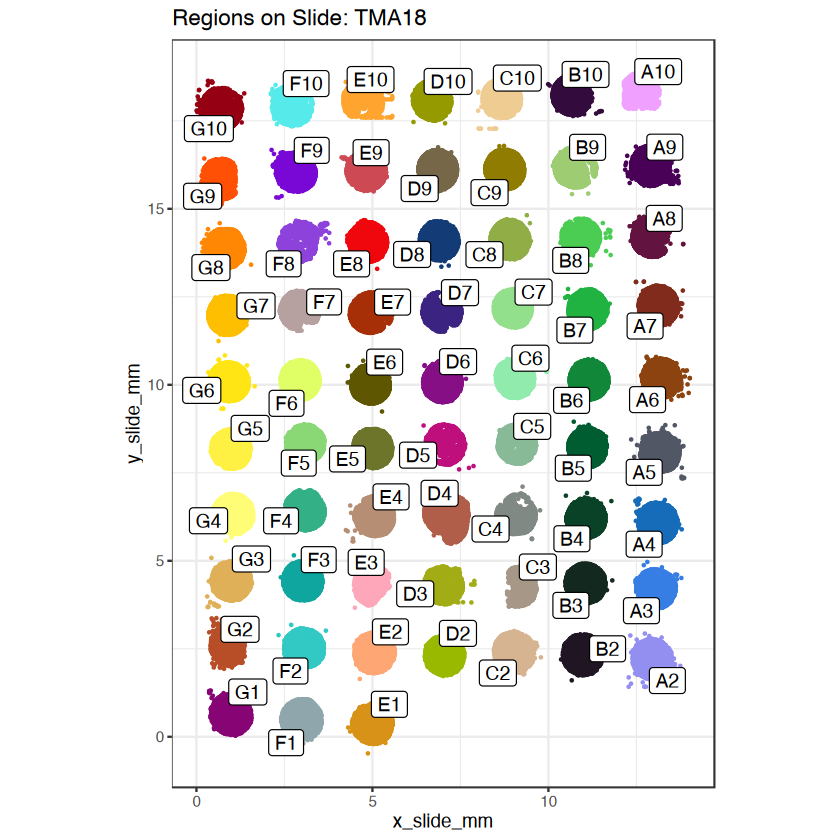

In [86]:
md <- seu.obj@meta.data
cluster_col <- "location"

xyplot(cluster_col, x_column = "x_slide_mm", y_column = "y_slide_mm", 
                   metadata = md, 
                   alphasize = 1, show_legend = FALSE, show_labels = TRUE,
  label_color = "black",
  label_repel = TRUE) + ggtitle(paste("Regions on Slide:", slide_name))

### Slide 2

### Add additional slides if necessary

## Quality Control Analysis

In [87]:
# Create QC Report for each individual slide
# qc_all_slides(all_seurat_objects, outdir = out_dir, region_col = "location")
qc_all_slides(all_seurat_objects, outdir = out_dir, region_col = "location", fov_plots = FALSE)

Running QC for: TMA18

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



## Quality Control Filtering (Cell Level)

In [88]:
custom_thresholds <- list()

for (slide_name in names(all_seurat_objects)) {
    custom_thresholds[[slide_name]] <- list(lower = 50, upper = 10000)
}

custom_thresholds

$TMA18
$TMA18$lower
[1] 50

$TMA18$upper
[1] 10000

In [89]:
# Filter objects based on quality control

# result <- suppressWarnings(filter_seurat_objects(all_seurat_objects, thresholds_list = NULL))
result <- filter_seurat_objects(all_seurat_objects, thresholds_list = custom_thresholds, flag_col = "qcCellsFlagged", low_thres = 0.025, high_thres = 0.975, area_upper = 600, area_lower = 40, region_col = "region", min_cells_per_region = 500)
filtered_objects <- result$filtered_objects
filter_log <- result$filter_log

# Clean up
rm(result)
gc()

# Info
filter_log

Filtering: TMA18

Counting flagged cells before filtering TMA18

Determining thresholds TMA18

Filtering flagged cells for TMA18

  Regions dropped: 1 (Total cells removed from these regions: 0)

Filtered slide: TMA18  | Total cells: 227417  | Cells removed: 19384  | Cells removed (calc): 19384 | Remaining cells: 208033



,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,4689280,250.5,6896012,368.3,NA,6896012,368.3
Vcells,1387626587,10586.8,2813676308,21466.7,32768,2684467507,20480.9


Slide,Total_Cells,Bottom_Threshold,Bottom_Removed,Bottom_Percent,Top_Threshold,Top_Removed,Top_Percent,Flagged_Before_Threshold,Flagged_After_Threshold,Flagged_Removed,Flagged_Percent,Border_Removed,Area_Upper_Threshold,Area_Lower_Threshold,Area_Removed,Remaining_Cells,Remaining_Percent,Cells_Removed,Cells_Removed_Percent
<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>
TMA18,227417,50,6676,2.94,10000,794,0.35,1880,9,9,0,4793,600,40,7112,208033,91.48,19384,8.52


## Quality Control Filtering (FOV Level)

In [90]:
# source the FOV QC tool:
source("https://raw.githubusercontent.com/Nanostring-Biostats/CosMx-Analysis-Scratch-Space/Main/_code/FOV%20QC/FOV%20QC%20utils.R")

# load necessary information for the QC tool: the gene to barcode map:
allbarcodes <- readRDS(url("https://github.com/Nanostring-Biostats/CosMx-Analysis-Scratch-Space/raw/Main/_code/FOV%20QC/barcodes_by_panel.RDS"))
names(allbarcodes)

# get the barcodes for the panel we want:
barcodemap <- allbarcodes$Hs_6k    # <------- choose the right map for your panel
head(barcodemap)

[1] "Hs_IO"    "Hs_UCC"   "Hs_6k"    "Mm_Neuro" "Mm_UCC"   "Hs_WTX"

,gene,barcode
,<chr>,<chr>
1,A1BG,......YY..........................GG..........GG..GG..
2,A2M,........GG......YY................GG......BB..........
3,AAAS,........BB........RR....GGYY..........................
4,AAK1,YY..........YY......YY............BB..................
5,AAMP,..........BB..........YY......YY..BB..................
6,AARS1,......GGYY............BB............BB................


In [91]:
# Define Params
sdimx_col <- "x_slide_mm"
sdimy_col <- "y_slide_mm"
fov_col <- "fov"

for (slide_name in names(filtered_objects)) {
    message("Filtering FOVs: ", slide_name)
    seu_filtered <- filtered_objects[[slide_name]]
    counts <- Matrix::t(Seurat::GetAssayData(seu_filtered, layer = "counts")) # cells in rows and genes in columns
    metadata <- seu_filtered@meta.data # row-aligned with the counts matrix
    xy <- as.matrix(metadata[, c(sdimx_col, sdimy_col)])
    ## run the method:
    fovqcresult <- runFOVQC(counts = counts, xy = xy, fov = metadata[[fov_col]], barcodemap = barcodemap)
    print("runFOVQC done, saving results...")
    saveRDS(fovqcresult, file =     file.path(out_dir, paste0("fovqcresult_", slide_name, ".RDS")))
    print("saved, plotting...")
    pdf(file.path(out_dir, paste0("FOV_QC_Results_", slide_name, ".pdf")), width = 14, height = 10)
    # map of flagged FOVs:
    mapFlaggedFOVs(fovqcresult)
    FOVSignalLossSpatialPlot(fovqcresult)
    # FOVEffectsHeatmap(fovqcresult) 

    # Count cells before filtering
    n_fovs_before  <- length(unique(seu_filtered@meta.data[[fov_col]]))
    n_cells_before <- ncol(seu_filtered)
    ## filter Seurat object by excluding flagged FOVs
    cells_keep <- rownames(seu_filtered@meta.data)[!seu_filtered@meta.data[[fov_col]] %in% fovqcresult$flaggedfovs]
    seu_filtered <- subset(seu_filtered, cells = cells_keep)
    ## drop unused FOV levels
    seu_filtered@meta.data[[fov_col]] <- droplevels(as.factor(seu_filtered@meta.data[[fov_col]]))
    # Count cells after filtering
    n_fovs_after  <- length(unique(seu_filtered@meta.data[[fov_col]]))
    n_cells_after <- ncol(seu_filtered)
    ## summary numbers
    fovs_removed  <- n_fovs_before - n_fovs_after
    cells_removed <- n_cells_before - n_cells_after

    grid::grid.newpage()
    # list FOVs flagged for any reason, for loss of signal, for bias:
    ## construct text
    all_fovs   <- paste(fovqcresult$flaggedfovs, collapse = ", ")
    count_fovs <- paste(fovqcresult$flaggedfovs_fortotalcounts, collapse = ", ")
    bias_fovs  <- paste(fovqcresult$flaggedfovs_forbias, collapse = ", ")

    qc_text <- paste0(
    "FOV QC summary for ", slide_name, "\n\n",

    "FOVs filtered (any reason): ",
    ifelse(nzchar(all_fovs), all_fovs, "none"), "\n",

    "FOVs filtered based on total counts: ",
    ifelse(nzchar(count_fovs), count_fovs, "none"), "\n",

    "FOVs filtered based on bias: ",
    ifelse(nzchar(bias_fovs), bias_fovs, "none"), "\n\n",

    "Summary statistics\n",
    "------------------\n",
    "Number of FOVs removed: ", fovs_removed, "\n",
    "Number of cells removed: ", cells_removed, "\n",
    "Remaining FOVs: ", n_fovs_after, "\n",
    "Remaining cells: ", n_cells_after
    )

    ## center text on the page
    grid::grid.text(
    qc_text,
    x = 0.5,
    y = 0.5,
    just = c("center", "center"),
    gp = grid::gpar(fontsize = 11)
    )
    dev.off()
    filtered_objects[[slide_name]] <- seu_filtered

    # Update filter_log
    total_cells <- filter_log[filter_log$Slide == slide_name, ]$Total_Cells[1]
    remaining_cells <- ncol(seu_filtered)
    removed_cells <- total_cells - remaining_cells

    filter_log[filter_log$Slide == slide_name, ]$Remaining_Cells[1] <- remaining_cells
    filter_log[filter_log$Slide == slide_name, ]$Remaining_Percent[1] <- round( (remaining_cells / total_cells) * 100, 2)
    filter_log[filter_log$Slide == slide_name, ]$Cells_Removed[1] <- removed_cells
    filter_log[filter_log$Slide == slide_name, ]$Cells_Removed_Percent[1] <- round(removed_cells / total_cells * 100, 2)
}

Filtering FOVs: TMA18

The following FOVs failed QC for one or more barcode positions: 19, 21, 277, 292, 344, 356, 441, 505



[1] "runFOVQC done, saving results..."
[1] "saved, plotting..."


In [92]:
# Create QC Report for each individual slide after filtering
qc_all_slides(filtered_objects, outdir = out_dir, file_prefix = "QC_Report_Filtered_", filter_log = filter_log, region_col = "location", fov_plots = FALSE)

Running QC for: TMA18



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



### Saving individual filtered objects 

In [93]:
for (slide_name in names(filtered_objects)) {
  seu_filtered <- filtered_objects[[slide_name]]
  saveRDS(seu_filtered, file.path(out_dir_seu, paste0("filtered_", slide_name, ".RDS")))
}

In [94]:
# clean up memory
rm(all_seurat_objects)
gc()

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,4712807,251.7,6896012,368.3,NA,6896012,368.3
Vcells,1631844365,12450.0,2813676308,21466.7,32768,2684467507,20480.9


## Merging individual objects (slides) into one

In [95]:
# Ensure unique cell IDs
for (slide_name in names(filtered_objects)) {

  # Rename cells with slide prefix
  filtered_objects[[slide_name]] <- RenameCells(
    filtered_objects[[slide_name]],
    new.names = paste0(filtered_objects[[slide_name]]@meta.data$slide_id, "_", filtered_objects[[slide_name]]@meta.data$cell_ID))

  # Add new unique cell ID column
  filtered_objects[[slide_name]]$cell_ID_new <- rownames(filtered_objects[[slide_name]]@meta.data)
}

In [96]:
# Merge all slides into one Seurat object
merged_obj <- merge(
  x = filtered_objects[[1]],
  y = filtered_objects[-1],
  project = "CosMx_RNA"
)

In [97]:
merged_obj
# colnames(merged_obj@meta.data)
unique(merged_obj@meta.data$slide_id)
head(merged_obj@meta.data)
str(merged_obj@meta.data$region)

An object of class Seurat 
6518 features across 206450 samples within 3 assays 
Active assay: RNA (6175 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: falsecode, negprobes

[1] "18"

,fov,Area,AspectRatio,x_FOV_px,y_FOV_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.G,⋯,her2_status_path,received_chemo,received_rad,received_horm,received_surgery,tumor_size_mm,reg_nodes_metastasis,reg_nodes_pos,reg_nodes_exam,cell_ID_new
,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
18_c_1_100_100,100,23200,0.79,1848,915,207,164,1099.8,3272,371.9,⋯,Negative,0,0,1,1,24,250,4,5,18_c_1_100_100
18_c_1_100_107,100,2805,0.92,1713,926,57,62,1391.7,3480,366.9,⋯,Negative,0,0,1,1,24,250,4,5,18_c_1_100_107
18_c_1_100_113,100,9714,0.87,2185,1009,133,153,1034.4,2408,332.1,⋯,Negative,0,0,1,1,24,250,4,5,18_c_1_100_113
18_c_1_100_123,100,6857,0.73,584,1043,83,113,871.4,1332,340.7,⋯,Negative,0,0,1,1,24,250,4,5,18_c_1_100_123
18_c_1_100_157,100,8809,0.99,2257,1291,109,110,782.8,4068,274.9,⋯,Negative,0,0,1,1,24,250,4,5,18_c_1_100_157
18_c_1_100_165,100,11665,0.95,2513,1372,129,136,1151.3,3044,328.0,⋯,Negative,0,0,1,1,24,250,4,5,18_c_1_100_165


 chr [1:206450] "13" "13" "13" "13" "13" "13" "13" "13" "13" "13" "13" "13" ...


In [98]:
# Reorder regions
merged_obj@meta.data$region <- factor(
  merged_obj@meta.data$region,
  levels = mixedsort(unique(merged_obj@meta.data$region))
)

In [99]:
# Offset x-coordinates so slides don't overlap
# Apply sequential offsets for each slide beyond the first
# Get maximum width per slide and apply cumulative shifts

slide_names <- names(filtered_objects)
if (length(slide_names) > 1) {

  offsets <- c(0)  # first slide stays at 0

  for (i in 2:length(slide_names)) {

    prev_slide <- sub("^TMA", "", slide_names[i - 1])
    this_slide <- sub("^TMA", "", slide_names[i])
    
    # Find max x of the previous slide
    prev_max <- max(
      merged_obj@meta.data$x_slide_mm[merged_obj@meta.data$slide_id == prev_slide],
      na.rm = TRUE
    )
    
    # Define offset as previous max + 1 (mm)
    offsets[i] <- prev_max + 1
    
    # Apply offset to current slide
    merged_obj@meta.data$x_slide_mm[merged_obj@meta.data$slide_id == this_slide] <-
      merged_obj@meta.data$x_slide_mm[merged_obj@meta.data$slide_id == this_slide] + offsets[i]
  }
} else {
  message("Single slide detected. Skipping spatial offsets.")
}

Single slide detected. Skipping spatial offsets.



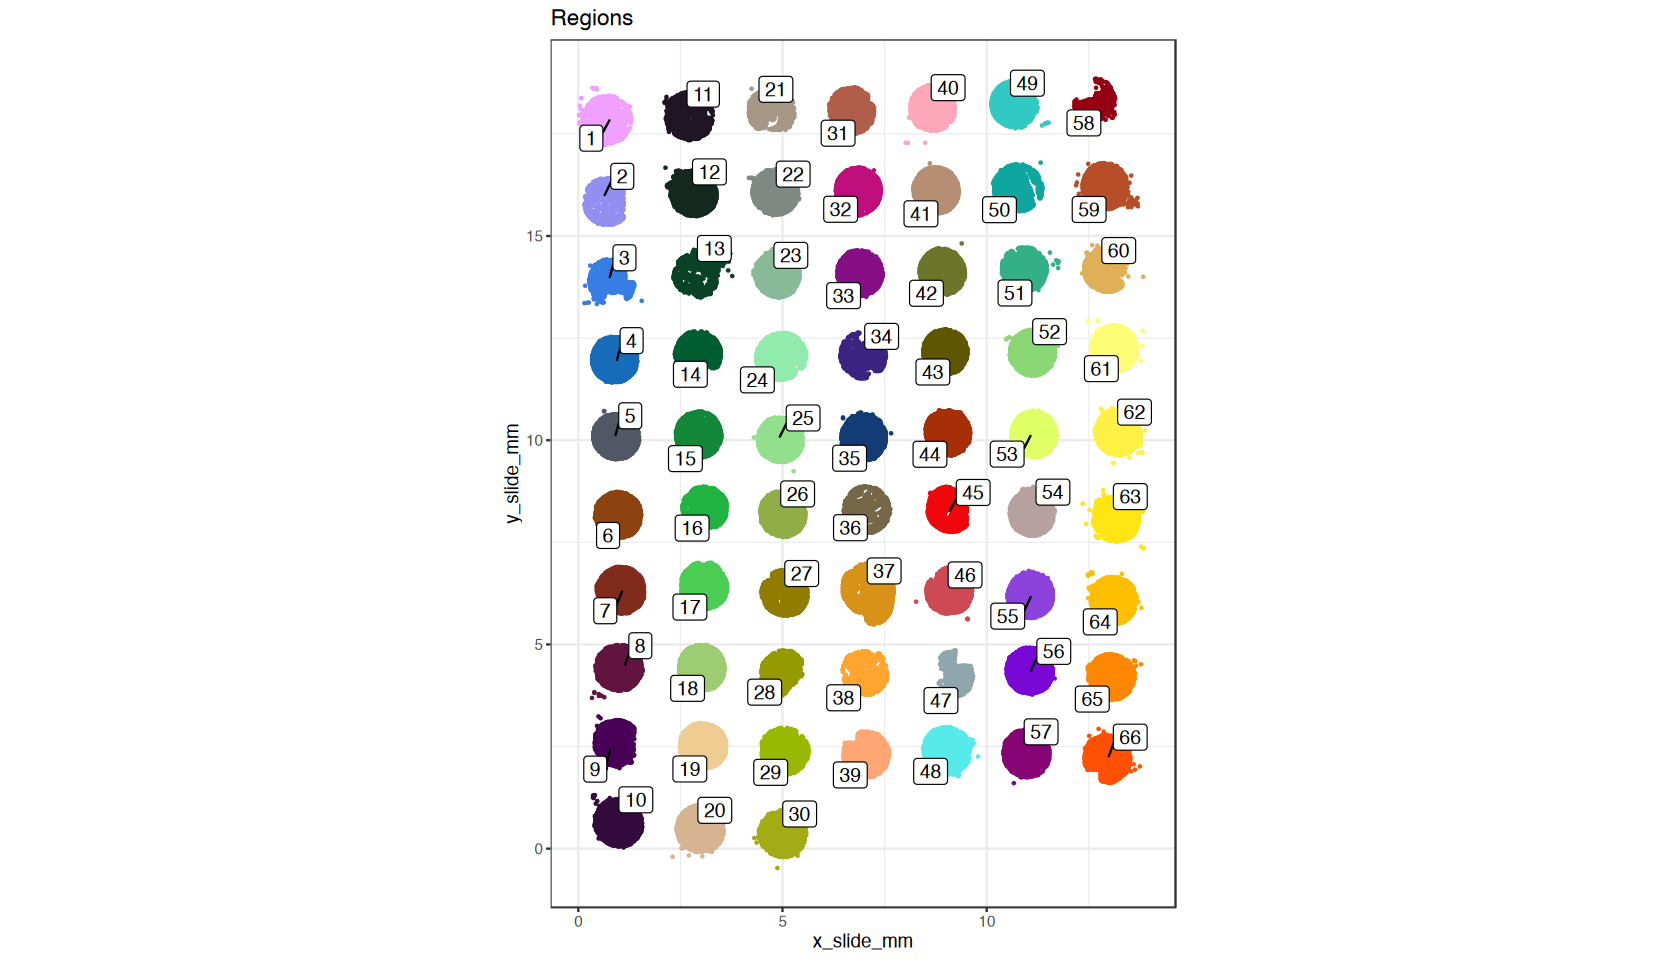

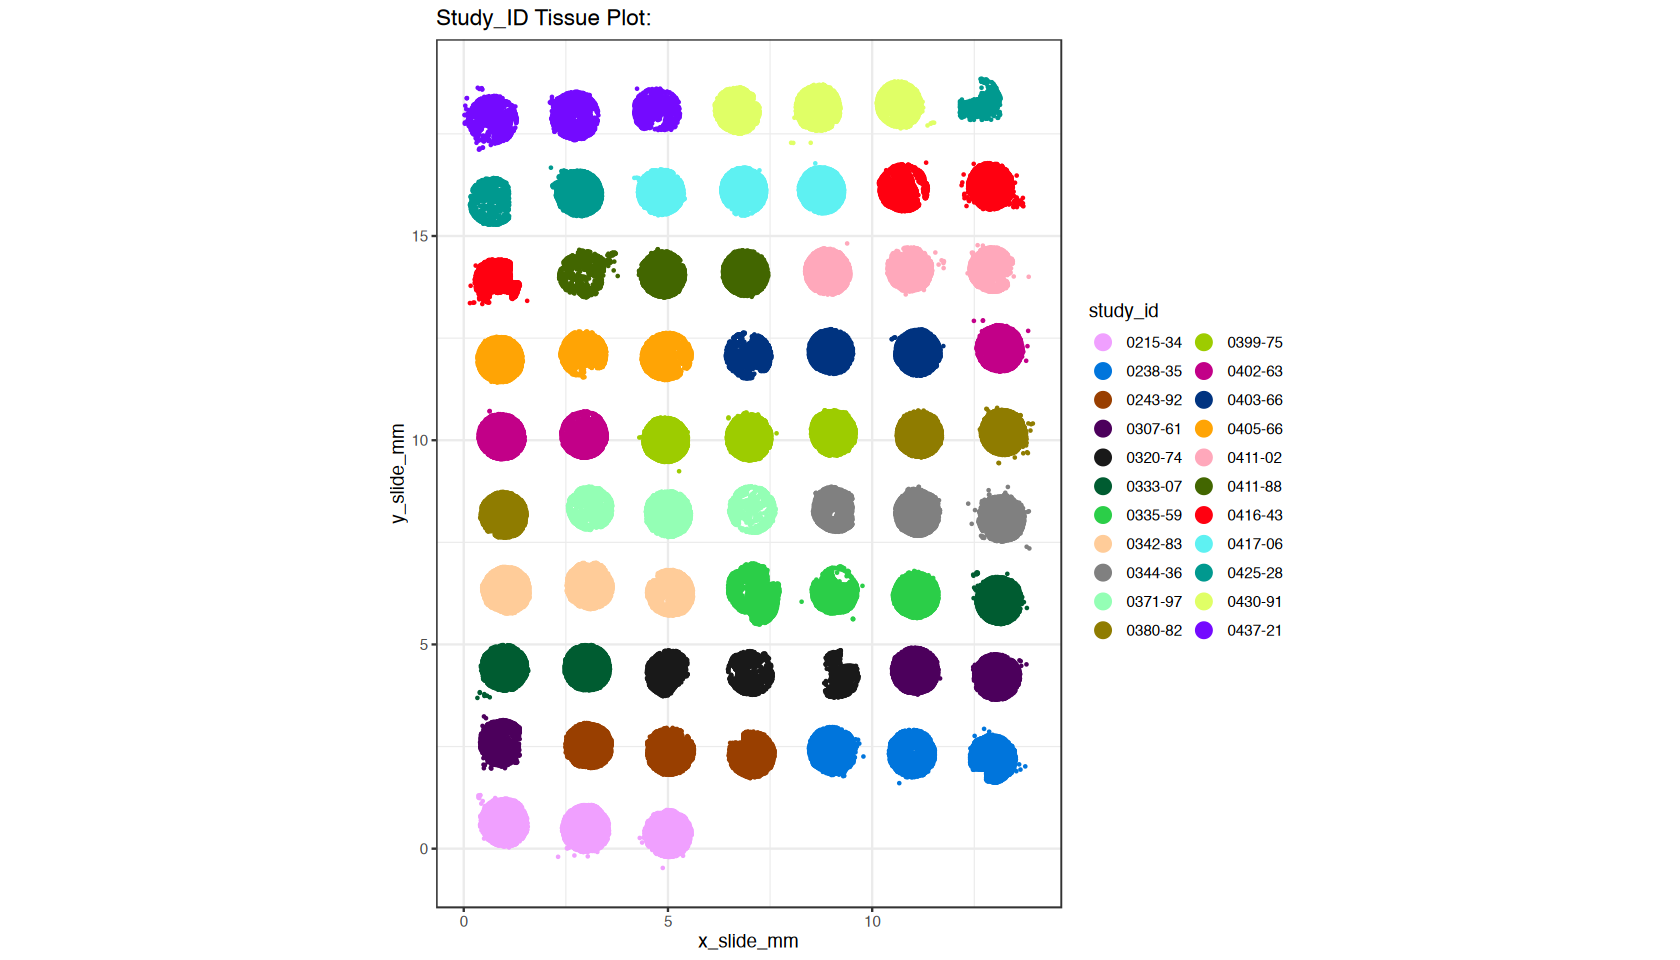

In [100]:
# Visualize to check if offsets are correct
options(repr.plot.width=14, repr.plot.height=8)

# Tissue plot from metadata
cluster_col <- "region"

xyplot(cluster_col, x_column = "x_slide_mm", y_column = "y_slide_mm", 
                   metadata = merged_obj@meta.data, 
                   alphasize = 1, show_legend = FALSE, show_labels = TRUE,
  label_color = "black",
  label_repel = TRUE) + ggtitle(paste("Regions"))


cluster_col <- "study_id"
xyplot(cluster_col, x_column = "x_slide_mm", y_column = "y_slide_mm", 
                   metadata = merged_obj@meta.data, 
                   alphasize = 1, show_legend = TRUE, show_labels = FALSE) + 
  ggtitle(paste("Study_ID Tissue Plot:"))

In [101]:
# clean up memory
rm(filtered_objects)
gc()

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,4765172,254.5,8382395,447.7,NA,6896012,368.3
Vcells,1490450250,11371.3,2813676308,21466.7,32768,2684467507,20480.9


In [90]:
# Create QC Report for merged object
qc_report(merged_obj, "All_Slides", out_dir, file_prefix = "QC_Report_Merged_", region_col = "region")
# qc_report(merged_obj, "All_Slides", out_dir, file_prefix = "QC_Report_Merged_byPatient_", region_col = "study_id")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" 

ERROR: [1m[33mError[39m in `seu[["negprobes"]]`:[22m
[33m![39m ‘negprobes’ not found in this Seurat object
 


### Saving merged object

In [102]:
merged_obj

An object of class Seurat 
6518 features across 206450 samples within 3 assays 
Active assay: RNA (6175 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: falsecode, negprobes

In [103]:
saveRDS(merged_obj, file.path(out_dir_seu, paste0("merged_object_", study_name, ".RDS")))

# STOP HERE AND MOVE TO CELLTYPING

# Testing

In [126]:
all_seurat_objects <- load_seurat_objects(data_dir)
seu <- all_seurat_objects[[1]]

[1] "../raw_data/TMA18/seuratObject_TMA18.RDS"            
[2] "../raw_data/TMA18/seuratObject_TMA18_transcripts.RDS"
[1] "TMA18"             "TMA18_transcripts"
[1] "Removing assay: QC_Normalization.RNA.1_1"
[1] "Removing assay: QC_Normalization.RNA.1_1"


In [129]:
colnames(seu@meta.data)

[1] "fov"                                                                      
  [2] "Area"                                                                     
  [3] "AspectRatio"                                                              
  [4] "x_FOV_px"                                                                 
  [5] "y_FOV_px"                                                                 
  [6] "Width"                                                                    
  [7] "Height"                                                                   
  [8] "Mean.PanCK"                                                               
  [9] "Max.PanCK"                                                                
 [10] "Mean.G"                                                                   
 [11] "Max.G"                                                                    
 [12] "Mean.Membrane"                                                            
 [13] "Max.Membrane"                                                             
 [14] "Mean.CD45"                                                                
 [15] "Max.CD45"                                                                 
 [16] "Mean.DAPI"                                                                
 [17] "Max.DAPI"                                                                 
 [18] "SplitRatioToLocal"                                                        
 [19] "NucArea"                                                                  
 [20] "NucAspectRatio"                                                           
 [21] "Circularity"                                                              
 [22] "Eccentricity"                                                             
 [23] "Perimeter"                                                                
 [24] "Solidity"                                                                 
 [25] "cell_id"                                                                  
 [26] "assay_type"                                                               
 [27] "version"                                                                  
 [28] "Run_Tissue_name"                                                          
 [29] "Panel"                                                                    
 [30] "cellSegmentationSetId"                                                    
 [31] "cellSegmentationSetName"                                                  
 [32] "slide_ID_numeric"                                                         
 [33] "x_slide_mm"                                                               
 [34] "y_slide_mm"                                                               
 [35] "cell_ID"                                                                  
 [36] "unassignedTranscripts"                                                    
 [37] "median_RNA"                                                               
 [38] "RNA_quantile_0.75"                                                        
 [39] "RNA_quantile_0.8"                                                         
 [40] "RNA_quantile_0.85"                                                        
 [41] "RNA_quantile_0.9"                                                         
 [42] "RNA_quantile_0.95"                                                        
 [43] "RNA_quantile_0.99"                                                        
 [44] "nCount_RNA"                                                               
 [45] "nFeature_RNA"                                                             
 [46] "median_negprobes"                                                         
 [47] "negprobes_quantile_0.75"                                                  
 [48] "negprobes_quantile_0.8"                                                   
 [49] "negprobes_quantile_0.85"                                   

In [ ]:
# Define thresholds
min_px <- 36
max_px <- 4220

# Create the logical flag in metadata
seu@meta.data$fov_border <- ifelse(
  seu@meta.data$x_FOV_px < min_px | seu@meta.data$x_FOV_px > max_px | 
  seu@meta.data$y_FOV_px < min_px | seu@meta.data$y_FOV_px > max_px, 
  "Border", "NoBorder"
)

# Preview the counts to see how many cells are affected
table(seu@meta.data$fov_border)
n_close <- sum(seu@meta.data$fov_border == "Border")
n_far <- sum(seu@meta.data$fov_border == "NoBorder")
print(paste("Border:", n_close, "NoBorder:", n_far))
print(paste("Border %:", round(n_close / (n_close + n_far) * 100, 2), "%"))


  Border NoBorder 
    5524   225572 

[1] "Border: 5524 NoBorder: 225572"
[1] "Border %: 2.39 %"


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


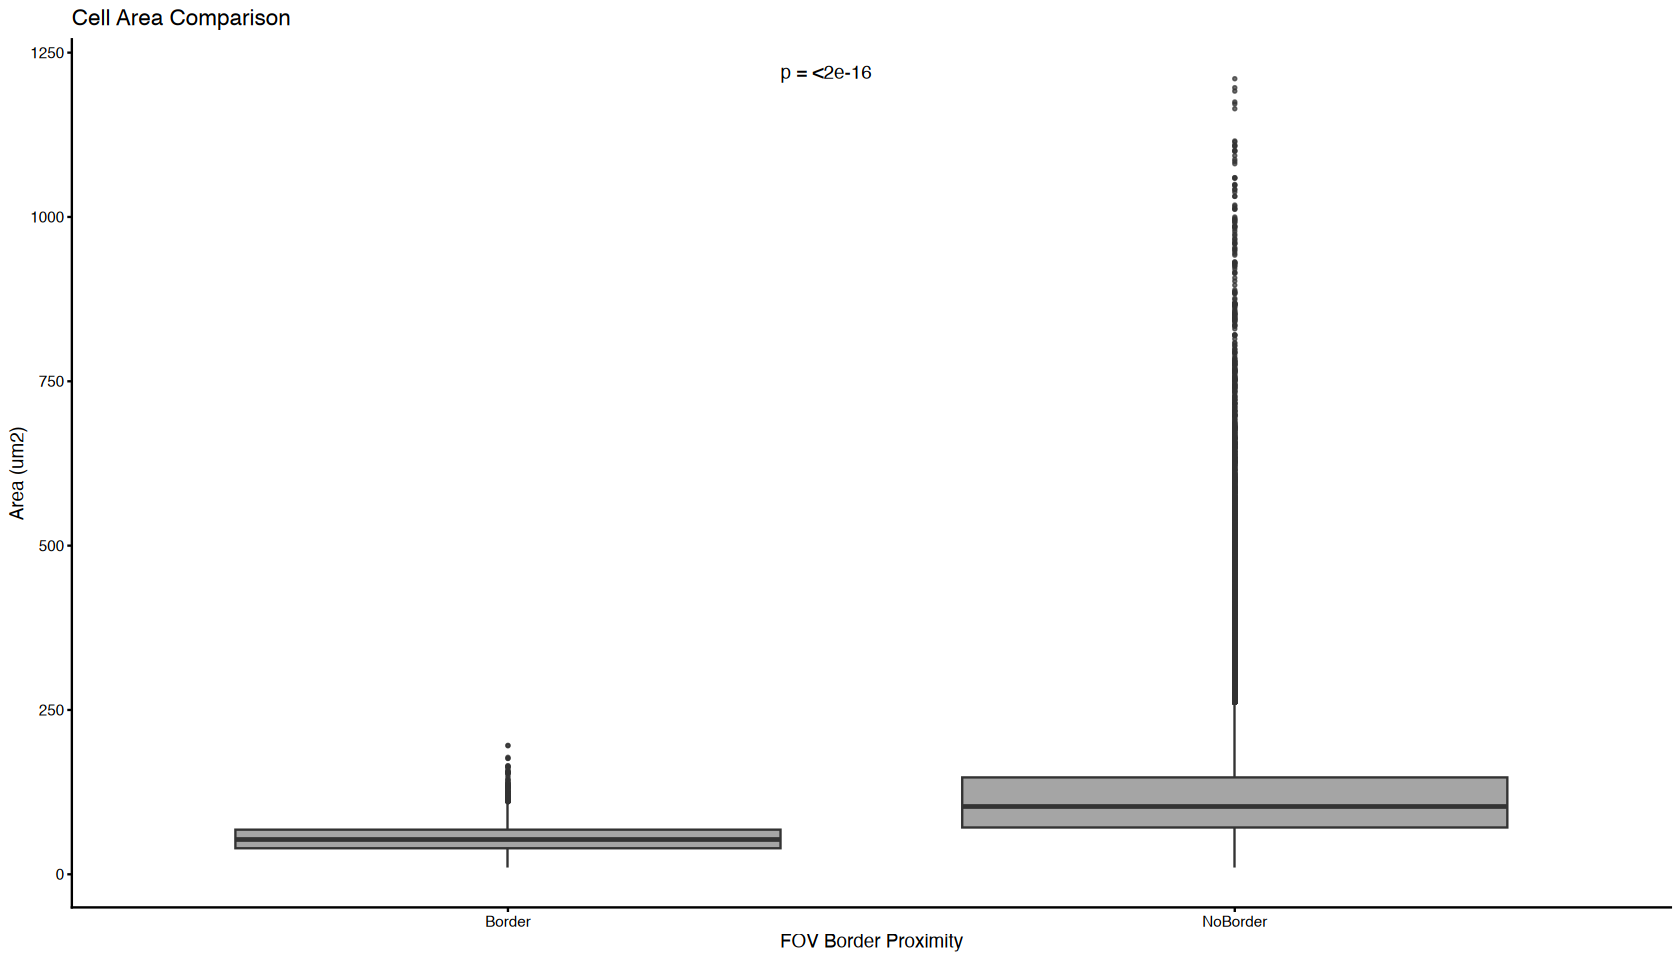

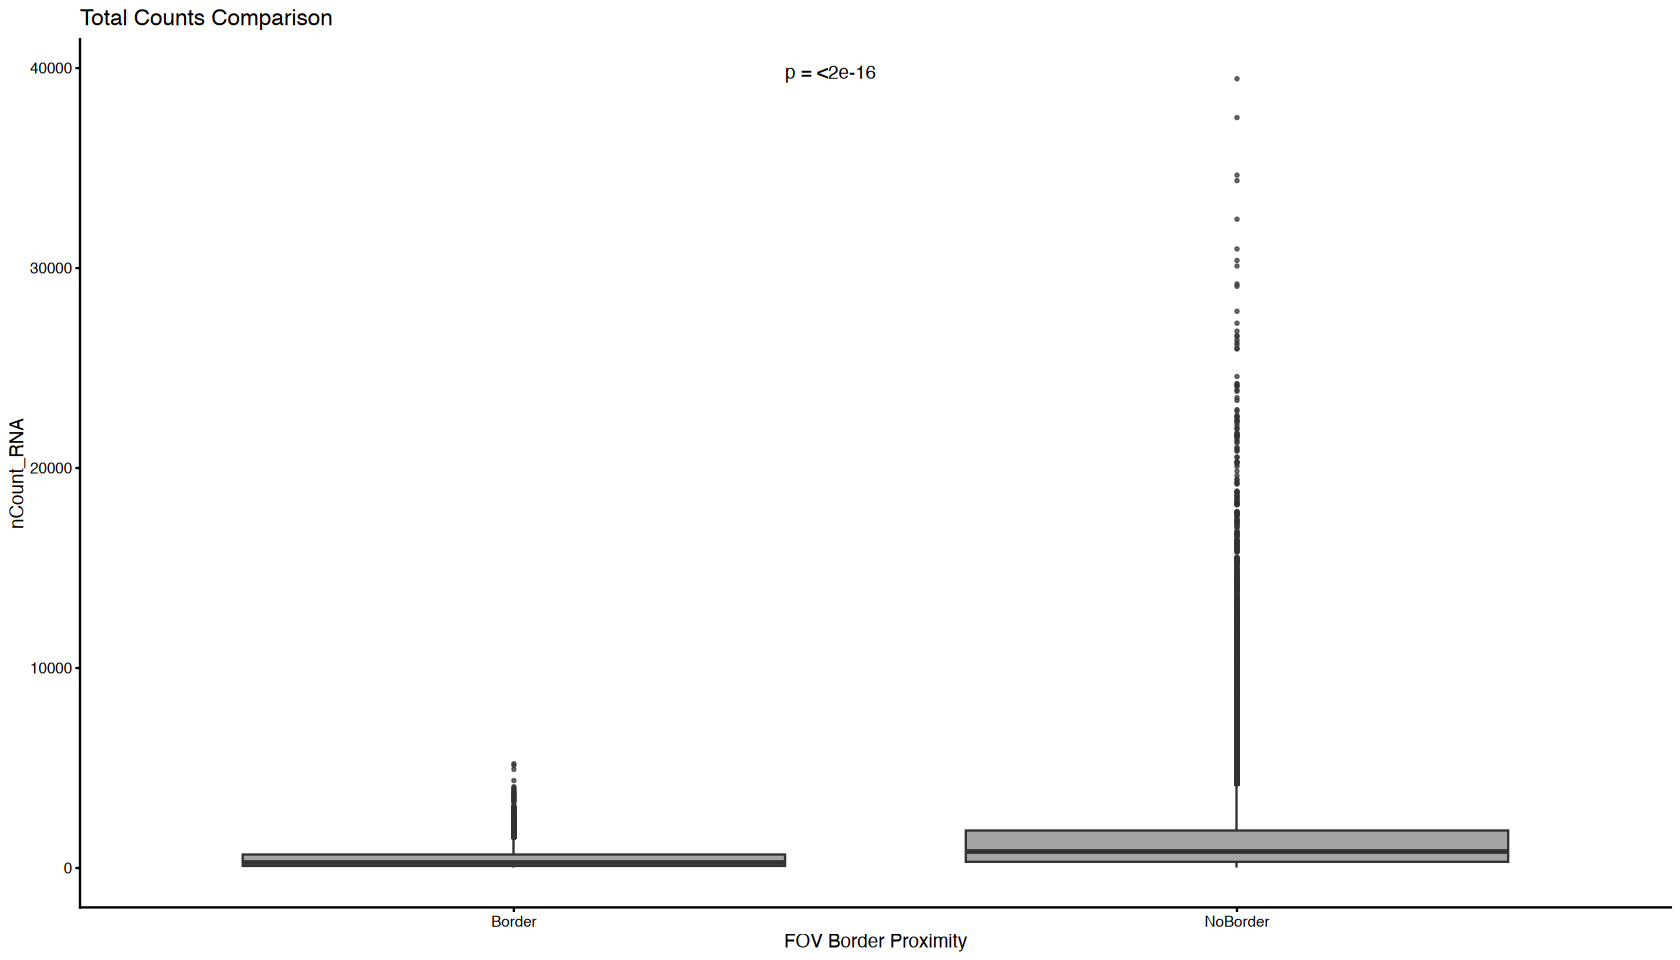

In [137]:
make_boxplot <- function(data, feature, title, y_label) {
  ggplot(data, aes_string(x = "fov_border", y = feature, fill = "fov_border")) +
    geom_boxplot(outlier.size = 0.5, alpha = 0.7) +
    stat_compare_means(method = "wilcox.test", label = "p.format", label.x = 1.4) +
    scale_fill_manual(values = c("Close" = "#E41A1C", "Far" = "#377EB8")) +
    labs(title = title, y = y_label, x = "FOV Border Proximity") +
    theme_classic() +
    theme(legend.position = "none")
}

# Generate both plots
p1 <- make_boxplot(seu@meta.data, "Area.um2", "Cell Area Comparison", "Area (um2)")
p2 <- make_boxplot(seu@meta.data, "nCount_RNA", "Total Counts Comparison", "nCount_RNA")

# Display side-by-side
p1
p2

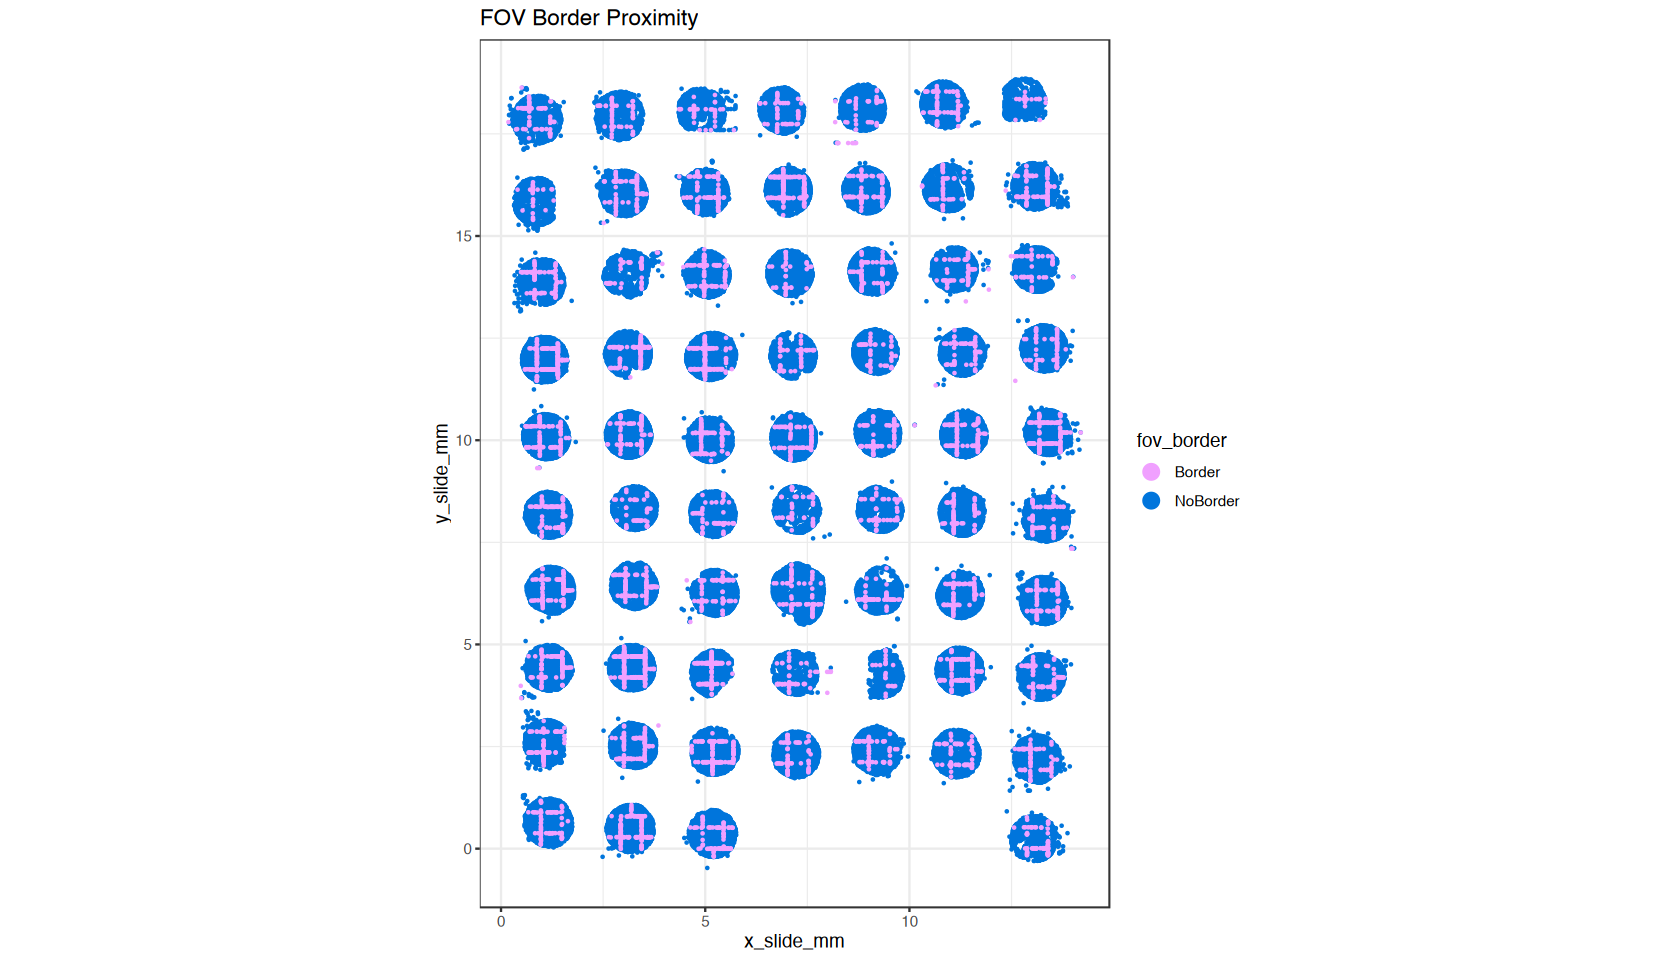

In [141]:
xyplot('fov_border', x_column = "x_slide_mm", y_column = "y_slide_mm", 
                   metadata = seu@meta.data, ptsize = 0.25, plotfirst = "NoBorder",
                   alphasize = 1, show_legend = TRUE, show_labels = FALSE) +
                   ggtitle(paste("FOV Border Proximity"))

## Downstream Analysis with scPearsonPCA

see https://nanostring-biostats.github.io/CosMx-Analysis-Scratch-Space/posts/pearsonpca/

In [31]:
# # read in merged object (optional)
# merged_obj <- readRDS(file.path(out_dir, paste0("merged_object_", study_name, ".RDS")))

### No Batch Correction

#### scPearsonPCA

In [ ]:
# Define parameters
nfeatures = 3000
run_prefix <- "scpearson"
run_suffix <- "nobatch"
slot_names = list(
    pca = paste0(run_prefix, "_pca_", run_suffix),
    umap = paste0(run_prefix, "_umap_", run_suffix),
    graph = paste0(run_prefix, "_graph_", run_suffix),
    clusters = paste0(run_prefix, "_clusters_", run_suffix)
    )

In [33]:
# Run scPearsonPCA
results <- suppressMessages(suppressWarnings(
  apply_scPearsonPCA(merged_obj, nfeatures = nfeatures, slot_names = slot_names)
))

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 534504
Number of edges: 14017191

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8377
Number of communities: 28
Elapsed time: 152 seconds


In [34]:
# Save results back as merged object
merged_obj <- results$seu

In [35]:
# Visualize outcome
reduction <- slot_names$umap
slide_name <- paste0(run_prefix, "_", run_suffix)
cluster_col <- c(slot_names$clusters)


# Plot umaps
umap_plots(merged_obj, 
            slide_name = slide_name, 
            outdir = out_dir, 
            file_prefix = "UMAPS_", 
            reduction = reduction,
            cluster_col = cluster_col)

# Plot xy plots
xy_plots(merged_obj,
        slide_name = slide_name,
        outdir = out_dir,
        file_prefix = "XY_PLOTS_",
        cluster_col = cluster_col,
        shuffle = TRUE,
        show_legend = TRUE)

# Plot xy plots per region
suppressWarnings(xy_plots_by_region(
  merged_obj,
  slide_name = slide_name,
  outdir = out_dir,
  file_prefix = "XY_ZOOM_",
  cluster_col = cluster_col,
  region_col = "region",
  regions_per_page = 2,
  shuffle = TRUE,
  show_legend = TRUE))

Summary plots saved for slide: scpearson_nobatch

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Summary plots saved for slide: scpearson_nobatch

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, w

### Saving merged object with dimensionality reductions and unsupervised clustering

In [40]:
saveRDS(merged_obj, file.path(out_dir, paste0("merged_object_scpearsonpca_", study_name, ".RDS")))

## Normalization

In [41]:
# # read in merged object (optional)
# merged_obj <- readRDS(file.path(out_dir, paste0("merged_object_scpearsonpca_", study_name, ".RDS")))

### Total Counts Normalization

In [ ]:
# Define parameters
ASSAY_NAME <- "RNA"

# Check status
Assays(merged_obj)
Layers(merged_obj[[ASSAY_NAME]])

In [45]:
# perform total counts normalization
normed <- totalcount_norm(Matrix::t(merged_obj[[ASSAY_NAME]]$counts))

In [46]:
# Save results back to seurat object
merged_obj <- Seurat::SetAssayData(merged_obj, layer = "data", new.data = Matrix::t(normed))

In [47]:
# Check status after normalization
Assays(merged_obj)
Layers(merged_obj[[ASSAY_NAME]])

[1] "RNA"       "falsecode" "negprobes"

[1] "counts" "data"

### Saving normalized Object

In [48]:
saveRDS(merged_obj, file.path(out_dir, paste0("merged_object_normalized_", study_name, ".RDS")))

### Check memory space

In [49]:
obj_sizes <- sapply(ls(), function(x) object.size(get(x)))
data.frame(
  object = names(obj_sizes),
  size_MB = round(obj_sizes / 1024^2, 2)
)[order(obj_sizes, decreasing = TRUE), ]


,object,size_MB
,<chr>,<dbl>
results,results,7294.17
merged_obj,merged_obj,7253.21
seu.obj,seu.obj,4074.03
seu_filtered,seu_filtered,3496.25
normed,normed,2549.95
md,md,275.63
metadata_csv,metadata_csv,0.14
qc_report,qc_report,0.12
xyplot,xyplot,0.10


# Testing

In [1]:
# Load Packages
library(Seurat)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(harmony)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(cluster)
library(ggrepel)
library(gtools)
library(tibble)
library(scPearsonPCA)
library(fs)

# Load helper functions
source("helper_functions.R")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: Rcpp



In [2]:
# Define directories
data_dir <- "../raw_data/TMA18" # Folder containing Seurat objects
seu_file_path <- file.path(data_dir, "seuratObject_TMA18_transcripts.RDS")
tx_file_path <- file.path(data_dir, "TMA18_tx_file.csv.gz")
metadata_file <- "../raw_data/sample_metadata.csv"
out_dir <- "../output" # Folder for outputs
study_name <- "TMA18"
out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
out_dir <- file.path(out_dir, study_name, "ReSeg")
txDir <- file.path(out_dir, "perFOV_txFile")
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)
dir.create(txDir, showWarnings = FALSE, recursive = TRUE)

# Load Reference for (semi) supervised clustering
reference_path <- "../raw_data/InsituType_reference/BreastCancer_6k.profiles.csv"

In [3]:
# Load Seurat object
seu <- readRDS(seu_file_path)
if ("QC_Normalization.RNA.1_1" %in% names(seu@assays)) {
        seu[["QC_Normalization.RNA.1_1"]] <- NULL
      }
seu@images <- list()
seu <- suppressWarnings(suppressMessages(UpdateSeuratObject(seu)))


In [5]:
# Counts Data
ASSAY_NAME <- "RNA"
counts <- Matrix::t(seu[[ASSAY_NAME]]@counts)

In [6]:
refprofiles <- read.csv(file.path(reference_path), row.names = 1, header = TRUE)
refprofiles <- refprofiles[is.element(rownames(refprofiles), colnames(counts)), ]

# Force to Matrix
refProfiles_mat <- as.matrix(refprofiles)
storage.mode(refProfiles_mat) <- "numeric"
common_genes <- intersect(colnames(counts), rownames(refProfiles_mat))

print(paste("Final Genes:", length(common_genes)))
print(paste("Final Cell Types:", ncol(refProfiles_mat)))

[1] "Final Genes: 5741"
[1] "Final Cell Types: 16"


In [7]:
# Genes in your data but missing from the reference (The "dropped" 500 genes)
genes_only_in_counts <- setdiff(colnames(counts), rownames(refProfiles_mat))

# Genes in the reference but missing from your specific data
genes_only_in_ref <- setdiff(rownames(refProfiles_mat), colnames(counts))

# Print summaries
print(paste("Genes in counts but NOT in reference:", length(genes_only_in_counts)))
print(head(genes_only_in_counts, 20)) # Print first 20 names

print(paste("Genes in reference but NOT in counts:", length(genes_only_in_ref)))
print(head(genes_only_in_ref, 20))

[1] "Genes in counts but NOT in reference: 434"
 [1] "A1BG"    "AATK"    "ACAA2"   "ACAT2"   "ACKR1"   "ADGRE1"  "ADH1B"  
 [8] "ADIRF"   "AFF2"    "AGA"     "AGPAT5"  "AGRP"    "AK1"     "ALDH1L1"
[15] "ANAPC16" "ANGPTL4" "ANXA2"   "AP1S2"   "AP4E1"   "APOA1"  
[1] "Genes in reference but NOT in counts: 0"
character(0)


In [8]:
# Create a data frame for the missing genes
genes_to_export <- data.frame(GeneName = genes_only_in_counts)

# Export to CSV
write.csv(genes_to_export, 
          file = file.path(out_dir, "genes_only_in_counts.csv"), 
          row.names = FALSE)

print("Export complete: genes_only_in_counts.csv")

[1] "Export complete: genes_only_in_counts.csv"
